# Lead Scoring — ANN Hyperparameter Search
#
# **Primary KPI**: `AUC × 100 + decile_gap_pp`  (higher = better)
#
# | Metric | What it measures |
# |---|---|
# | AUC | rank-ordering quality (0-1 → 0-100 after scaling) |
# | decile_gap_pp | D10 SE − D1 SE (percentage points, 0-100) |
# | composite | AUC×100 + gap_pp — single number to maximise |
#
# Notebook sections:
# 1. Config & Imports
# 2. Data Load & Feature Selection
# 3. Prep, Scaling & Train/Test Split
# 4. Evaluation Utilities
# 5. ANN Architecture
# 6. ANN Hyperparameter Sweep
# 7. Leaderboard
# 8. Best-Model Deep Dive (decile curve, ROC)
# 9. Correlation & Collinearity Analysis
# 10. Comparison with Existing Scores

## 1 · Config & Imports

In [3]:
import re
import pandas as pd
import numpy as np
import time
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

from itertools import product as iterproduct

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── plot theme ──
plt.rcParams.update({
    "figure.facecolor": "#0a0e17",
    "axes.facecolor":   "#111827",
    "axes.edgecolor":   "#1e293b",
    "axes.labelcolor":  "#9ca3af",
    "xtick.color":      "#6b7280",
    "ytick.color":      "#6b7280",
    "text.color":       "#e2e8f0",
    "grid.color":       "#1e293b",
    "font.family":      "monospace",
    "font.size":        10,
})
AMBER  = "#f0b429"
BLUE   = "#60a5fa"
GREEN  = "#10b981"
RED    = "#ef4444"
PURPLE = "#a78bfa"
CYAN   = "#22d3ee"
PINK   = "#f472b6"
GRAY   = "#4a5568"

# ── sweep config ──
N_RANDOM_SAMPLES = 60         # random combos to sample
TEST_SIZE        = 0.30
VAL_FRAC         = 0.15       # carved from train for early stopping
RANDOM_STATE     = 42
FILL_VALUE       = -999

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## 2 · Data Load & Feature Selection

In [4]:
df = pd.read_hdf("../reports/test_scored.h5", "df")
print(f"Shape before ops merge: {df.shape}")

# ── MERGE PARTNER OPS (TRAIN window — leak-free) ──
df_ops_train = pd.read_csv("../reports/partner_ops_train_vector.csv")
print(f"Ops train: {df_ops_train.shape}")

# Infer temporal windows from CSV columns (no data_lib import needed)
TEMPORAL_WINDOWS = sorted([
    int(c.replace("se_", "").replace("d", ""))
    for c in df_ops_train.columns
    if re.match(r"^se_\d+d$", c) and "delta" not in c
])
print(f"Temporal windows detected: {TEMPORAL_WINDOWS}")

smallest_wd = min(TEMPORAL_WINDOWS)
rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"se_{wd}d", f"decline_rate_{wd}d", f"median_response_min_{wd}d"]
    if wd != smallest_wd:
        rf_ops_cols += [
            f"se_delta_{smallest_wd}_{wd}",
            f"decline_rate_delta_{smallest_wd}_{wd}",
            f"response_delta_{smallest_wd}_{wd}",
        ]
rf_ops_cols += [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops_train.columns]
print(df.columns)
# Merge
df["partner_id"] = df["partner_id"].astype(str)
df_ops_train["partner_id"] = df_ops_train["partner_id"].astype(str)
df = df.merge(df_ops_train[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df = df.loc[:, ~df.columns.str.endswith("_ops")]
print(f"Shape after ops merge: {df.shape}")
print(f"Ops columns merged: {len(rf_ops_cols) - 1}")

TARGET = "installed_decision"

# ── LEAK-FREE FEATURES ──
FEATURES = [
    # ── SPATIAL — Gaussian KDE from training sources ──
    "predicted_field_hex",
    "predicted_field_hex_all_wmean",
    "predicted_field_hex_all_kswmean",
    "predicted_field_hex_all_min",
    "predicted_field_hex_all_max",
    "predicted_field_hex_all_std",
    "n_overlapping_hexes_field",
    "total_sources_all_hexes",
    "contested_field",

    # ── TEMPORAL FIELD ──
    "predicted_field_hex_30d",
    "predicted_field_hex_60d",
    "predicted_field_hex_365d",
    "field_momentum",

    # ── HEX CONSENSUS — shrunk SE from training ──
    "parent_se",
    "parent_total",
    "parent_color_numeric",
    "n_covering_partners",
    "parent_overlap",
    "install_velocity",

    # ── TEMPORAL HEX SE ──
    "weighted_se_30d_shrunk",
    "weighted_se_60d_shrunk",
    "weighted_se_365d_shrunk",
    "se_momentum",

    # ── HOP — neighbor SE aggregates ──
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "hop1_se_std",   "hop2_se_std",   "hop3_se_std",
    "hop1_count",    "hop2_count",    "hop3_count",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",

    # ── TEMPORAL HOP SE ──
    "hop1_se_30d_wmean",  "hop2_se_30d_wmean",  "hop3_se_30d_wmean",
    "hop1_se_60d_wmean",  "hop2_se_60d_wmean",  "hop3_se_60d_wmean",
    "hop1_se_365d_wmean", "hop2_se_365d_wmean", "hop3_se_365d_wmean",
    "se_gradient_1to3_30d",  "se_gradient_1to3_60d",  "se_gradient_1to3_365d",
    "se_confirmed_30d",      "se_confirmed_60d",      "se_confirmed_365d",

    # ── CONTESTED — overlap zone ──
    "contested_area_km2",
    "contested_radius_m",
    "contested_se",
    "contested_se_30d", "contested_se_60d", "contested_se_365d",
    "n_overlapping_partners",

    # ── BOUNDARY — cluster geometry ──
    "dist_to_boundary_edge_point_hex",
    "dist_to_cluster_center_point_hex",
    "depth_score_point_hex",
    "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    "worst_depth_score", "any_near_edge", "is_solo_cluster",

    # ── GEOMETRIC PATTERN ──
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m",
    "dense_score", "gully_score", "sparse_score",

    # ── TEMPORAL GEOMETRY ──
    "local_density_30d",  "local_density_60d",  "local_density_365d",
    "dense_score_30d",    "dense_score_60d",    "dense_score_365d",
    "sparse_score_30d",   "sparse_score_60d",   "sparse_score_365d",
    "spread_m_30d",       "spread_m_60d",       "spread_m_365d",

    # ── LEAD-LEVEL ──
    "hard_density",
    "density_regime",
    "min_dist",
]

# ── OPS FEATURES (TRAIN window — leak-free) ──
_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
FEATURES += _ops_feature_cols

available = [f for f in FEATURES if f in df.columns]
missing   = [f for f in FEATURES if f not in df.columns]
print(f"\nUsing {len(available)}/{len(FEATURES)} features, missing {len(missing)}:")
for m in missing:
    print(f"  - {m}")

ops_available = [f for f in _ops_feature_cols if f in df.columns]
print(f"\nOps features available: {len(ops_available)}/{len(_ops_feature_cols)}")
for f in ops_available:
    print(f"  + {f}")

Shape before ops merge: (18082, 204)
Ops train: (1475, 43)
Temporal windows detected: [30, 60, 365]
Index(['mobile', 'latitude', 'longitude', 'nmbr_partners_x', 'decision_time',
       'installed_decision', 'installed_time', 'hard_density',
       'density_regime', 'local_anisotropy',
       ...
       'norm_hop3_se_365d', 'norm_gradient_365d', 'norm_confirmed_365d',
       'norm_density_365d', 'norm_evidence_365d', 'norm_field_365d',
       'spatial_shrunk_30d', 'spatial_shrunk_60d', 'spatial_shrunk_365d',
       'boundary_dist_bucket'],
      dtype='str', length=204)
Shape after ops merge: (18082, 223)
Ops columns merged: 19

Using 111/111 features, missing 0:

Ops features available: 19/19
  + se_30d
  + decline_rate_30d
  + median_response_min_30d
  + se_60d
  + decline_rate_60d
  + median_response_min_60d
  + se_delta_30_60
  + decline_rate_delta_30_60
  + response_delta_30_60
  + se_365d
  + decline_rate_365d
  + median_response_min_365d
  + se_delta_30_365
  + decline_rate_delta

## 3 · Prep, Scaling & Train/Val/Test Split

ANNs need scaled inputs — we fit `StandardScaler` on **train only**, then transform val & test.

Also replace FILL_VALUE with 0 after scaling so the sentinel doesn't create outlier activations.

In [5]:
X = df[available].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]
X = X.fillna(FILL_VALUE)

print(f"Samples: {len(X)},  Features: {X.shape[1]},  Install rate: {y.mean():.4f}")

# ── Train / Test split (same as tree notebook) ──
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y.astype(int),
)

# ── Carve validation from train for early stopping ──
X_trn_raw, X_val_raw, y_trn, y_val = train_test_split(
    X_train_raw, y_train, test_size=VAL_FRAC, random_state=RANDOM_STATE, stratify=y_train.astype(int),
)

print(f"Train: {len(X_trn_raw)}  Val: {len(X_val_raw)}  Test: {len(X_test_raw)}")
print(f"Train SE: {y_trn.mean():.4f}  Val SE: {y_val.mean():.4f}  Test SE: {y_test.mean():.4f}")

# ── Fit scaler on train only ──
scaler = StandardScaler()
X_trn_sc  = scaler.fit_transform(X_trn_raw)
X_val_sc  = scaler.transform(X_val_raw)
X_test_sc = scaler.transform(X_test_raw)

# Replace FILL_VALUE-scaled artifacts with 0 (neutral after StandardScaler)
fill_scaled = scaler.transform(np.full((1, X_trn_raw.shape[1]), FILL_VALUE))
for col_idx in range(X_trn_sc.shape[1]):
    fv = fill_scaled[0, col_idx]
    X_trn_sc[X_trn_sc[:, col_idx] == fv, col_idx]  = 0.0
    X_val_sc[X_val_sc[:, col_idx] == fv, col_idx]   = 0.0
    X_test_sc[X_test_sc[:, col_idx] == fv, col_idx] = 0.0

# Also keep unscaled X_train/X_test for eval_model compatibility
X_train_sc_full = scaler.transform(X_train_raw)
fill_scaled2 = scaler.transform(np.full((1, X_train_raw.shape[1]), FILL_VALUE))
for col_idx in range(X_train_sc_full.shape[1]):
    fv = fill_scaled2[0, col_idx]
    X_train_sc_full[X_train_sc_full[:, col_idx] == fv, col_idx] = 0.0

print(f"\nScaler fitted. Feature means range: [{scaler.mean_.min():.2f}, {scaler.mean_.max():.2f}]")
print(f"Feature stds range:  [{scaler.scale_.min():.4f}, {scaler.scale_.max():.2f}]")

Samples: 18082,  Features: 111,  Install rate: 0.5794
Train: 10758  Val: 1899  Test: 5425
Train SE: 0.5795  Val SE: 0.5793  Test SE: 0.5794

Scaler fitted. Feature means range: [-999.00, 2131190.99]
Feature stds range:  [0.1327, 59886973.56]


## 4 · Evaluation Utilities

**Composite KPI** = `AUC × 100 + gap_pp`

- AUC ∈ [0.5, 1.0] → scaled to [50, 100]
- gap_pp = (D10_SE − D1_SE) × 100  → typically 0–60
- So composite ≈ 50–160 range; higher is better.

In [6]:
def eval_preds(p_train, y_tr, p_test, y_te):
    """Evaluate raw predictions. Returns dict with all metrics."""
    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    # Decile table on test
    edf = pd.DataFrame({"y": y_te.values if hasattr(y_te, 'values') else y_te, "p": p_test})
    edf["decile"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("decile").agg(n=("y", "count"), inst=("y", "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]

    d1_se  = tbl["se"].iloc[0]
    d10_se = tbl["se"].iloc[-1]
    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())

    composite = auc_test * 100 + gap_pp

    return {
        "auc_train":  round(auc_train, 4),
        "auc_test":   round(auc_test, 4),
        "gap_pp":     round(gap_pp, 2),
        "d1_se":      round(d1_se, 4),
        "d10_se":     round(d10_se, 4),
        "mono":       mono,
        "composite":  round(composite, 2),
        "decile_tbl": tbl,
    }


def print_leaderboard(results_df, title, top_n=15):
    """Print a compact leaderboard sorted by composite KPI."""
    df_s = results_df.sort_values("composite", ascending=False).head(top_n).reset_index(drop=True)
    print(f"\n{'='*100}")
    print(f"  {title}  (top {top_n} by composite = AUC×100 + gap_pp)")
    print(f"{'='*100}")
    cols = [c for c in df_s.columns if c != "decile_tbl"]
    print(df_s[cols].to_string(index=True))
    return df_s

## 5 · ANN Architecture

Configurable feedforward net: variable hidden layers, dropout, batch norm, activation.

In [7]:
class LeadScoringANN(nn.Module):
    """Feedforward ANN for lead scoring (binary output via sigmoid)."""

    def __init__(self, n_features, hidden_dims, dropout=0.3, use_batchnorm=True):
        super().__init__()
        layers = []
        prev = n_features
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_ann(
    X_trn, y_trn, X_val, y_val,
    hidden_dims, dropout, lr, weight_decay, batch_size,
    use_batchnorm=True,
    max_epochs=300, patience=20,
):
    """Train an ANN with early stopping on val AUC. Returns (model, history)."""
    n_feat = X_trn.shape[1]
    model = LeadScoringANN(n_feat, hidden_dims, dropout, use_batchnorm).to(DEVICE)

    # ── Class-weight for BCE ──
    pos_frac = y_trn.mean()
    pos_weight = torch.tensor([(1 - pos_frac) / pos_frac], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # We already have sigmoid in model, so use plain BCE for the forward pass
    # BUT — BCEWithLogitsLoss expects raw logits. Adjust: use BCELoss with sigmoid output.
    criterion = nn.BCELoss()

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=7)

    # ── Dataloaders ──
    t_X = torch.tensor(X_trn, dtype=torch.float32)
    t_y = torch.tensor(y_trn, dtype=torch.float32)
    t_Xv = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    t_yv = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    ds = TensorDataset(t_X, t_y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    best_val_auc = -1
    best_state   = None
    wait         = 0
    history      = {"train_loss": [], "val_auc": []}

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(ds)

        # ── Val AUC ──
        model.eval()
        with torch.no_grad():
            val_pred = model(t_Xv).cpu().numpy()
        val_auc = roc_auc_score(y_val, val_pred)

        history["train_loss"].append(epoch_loss)
        history["val_auc"].append(val_auc)
        scheduler.step(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    # Restore best
    model.load_state_dict(best_state)
    model.eval()
    return model, history, epoch + 1


def predict_np(model, X_np):
    """Run inference on numpy array, return numpy predictions."""
    model.eval()
    with torch.no_grad():
        t = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        return model(t).cpu().numpy()


print(f"ANN architecture ready. n_features = {len(available)}")

ANN architecture ready. n_features = 111


## 6 · ANN Hyperparameter Sweep

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── Improved ANN builder ──
class TabularANN(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.SiLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_ann_v2(X_trn, y_trn, X_val, y_val,
                 hidden_dims, dropout, lr, weight_decay,
                 batch_size, max_epochs=500, patience=40):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TabularANN(X_trn.shape[1], hidden_dims, dropout).to(device)

    ds_trn = TensorDataset(torch.tensor(X_trn, dtype=torch.float32),
                           torch.tensor(y_trn, dtype=torch.float32))
    dl_trn = DataLoader(ds_trn, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-6
    )

    best_val_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in dl_trn:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    return model, epoch + 1


def predict_ann(model, X):
    device = next(model.parameters()).device
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        return torch.sigmoid(model(X_t)).cpu().numpy()


# ── Sweep ──
ann_grid = {
    "hidden_dims": [
        [128, 64],
        [256, 128],
        [256, 128, 64],
        [128, 64, 32],
        [512, 256, 128],
        [256, 128, 64, 32],
    ],
    "dropout":      [0.1, 0.2, 0.3, 0.4],
    "lr":           [1e-3, 5e-4, 2e-4, 1e-4],
    "weight_decay": [1e-5, 1e-4, 1e-3],
    "batch_size":   [256, 512, 1024],
}

np.random.seed(RANDOM_STATE)
all_combos = list(iterproduct(*ann_grid.values()))
sample_idx = np.random.choice(len(all_combos), size=min(N_RANDOM_SAMPLES, len(all_combos)), replace=False)
sampled = [all_combos[i] for i in sample_idx]
print(f"ANN grid: {len(all_combos)} total combos → sampling {len(sampled)}")

y_trn_np   = y_trn.values.astype(np.float32)
y_val_np   = y_val.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

ann_results = []
best_composite = -np.inf

for hidden, drop, lr, wd, bs in tqdm(sampled, desc="ANN sweep"):
    try:
        model, n_epochs = train_ann_v2(
            X_trn_sc, y_trn_np, X_val_sc, y_val_np,
            hidden_dims=list(hidden), dropout=drop, lr=lr,
            weight_decay=wd, batch_size=bs,
            max_epochs=500, patience=40,
        )

        p_train = predict_ann(model, X_train_sc_full)
        p_test  = predict_ann(model, X_test_sc)
        ev = eval_preds(p_train, y_train, p_test, y_test)

        row = {
            "model": "ANN",
            "hidden_dims": str(hidden),
            "dropout": drop, "lr": lr, "weight_decay": wd,
            "batch_size": bs, "n_epochs": n_epochs,
            "auc_train":  ev["auc_train"],
            "auc_test":   ev["auc_test"],
            "gap_pp":     ev["gap_pp"],
            "mono":       ev["mono"],
            "composite":  ev["composite"],
        }
        ann_results.append(row)

        if ev["composite"] > best_composite:
            best_composite = ev["composite"]
            print(f"  NEW BEST → gap_pp={ev['gap_pp']:.2f}  auc={ev['auc_test']:.4f}  composite={ev['composite']:.2f}  [{hidden}  drop={drop}  lr={lr}]")

    except Exception as e:
        print(f"  FAILED: {hidden} drop={drop} lr={lr} — {e}")

print(f"\nANN sweep done — {len(ann_results)} experiments, best composite: {best_composite:.2f}")
ann_df = pd.DataFrame(ann_results)
print_leaderboard(ann_df, "ANN LEADERBOARD")

ANN grid: 864 total combos → sampling 60


ANN sweep:   2%|▏         | 1/60 [00:08<08:39,  8.80s/it]

  NEW BEST → gap_pp=54.33  auc=0.6672  composite=121.05  [[256, 128]  drop=0.2  lr=0.0002]


ANN sweep:  47%|████▋     | 28/60 [03:51<04:34,  8.59s/it]

  NEW BEST → gap_pp=54.70  auc=0.6652  composite=121.22  [[256, 128, 64]  drop=0.4  lr=0.0005]


ANN sweep:  50%|█████     | 30/60 [04:06<03:58,  7.97s/it]

  NEW BEST → gap_pp=55.80  auc=0.6635  composite=122.15  [[256, 128, 64]  drop=0.3  lr=0.001]


ANN sweep: 100%|██████████| 60/60 [08:13<00:00,  8.23s/it]


ANN sweep done — 60 experiments, best composite: 122.15

  ANN LEADERBOARD  (top 15 by composite = AUC×100 + gap_pp)
   model         hidden_dims  dropout      lr  weight_decay  batch_size  n_epochs  auc_train  auc_test  gap_pp   mono  composite
0    ANN      [256, 128, 64]      0.3  0.0010       0.00001         512       131     0.6868    0.6635   55.80  False     122.15
1    ANN      [256, 128, 64]      0.3  0.0010       0.00010         256        87     0.6945    0.6632   55.80  False     122.13
2    ANN      [256, 128, 64]      0.1  0.0005       0.00010        1024        66     0.7088    0.6657   55.43  False     122.00
3    ANN      [256, 128, 64]      0.1  0.0010       0.00010         256        69     0.7031    0.6646   55.25  False     121.71
4    ANN      [256, 128, 64]      0.4  0.0005       0.00100         256       153     0.6863    0.6652   54.70  False     121.22
5    ANN          [256, 128]      0.2  0.0002       0.00001         256       139     0.7073    0.6672   54.

,model,hidden_dims,dropout,lr,weight_decay,batch_size,n_epochs,auc_train,auc_test,gap_pp,mono,composite
0,ANN,"[256, 128, 64]",0.3,0.0010,0.00001,512,131,0.6868,0.6635,55.80,False,122.15
1,ANN,"[256, 128, 64]",0.3,0.0010,0.00010,256,87,0.6945,0.6632,55.80,False,122.13
2,ANN,"[256, 128, 64]",0.1,0.0005,0.00010,1024,66,0.7088,0.6657,55.43,False,122.00
3,ANN,"[256, 128, 64]",0.1,0.0010,0.00010,256,69,0.7031,0.6646,55.25,False,121.71
4,ANN,"[256, 128, 64]",0.4,0.0005,0.00100,256,153,0.6863,0.6652,54.70,False,121.22
5,ANN,"[256, 128]",0.2,0.0002,0.00001,256,139,0.7073,0.6672,54.33,True,121.05
6,ANN,"[256, 128, 64]",0.3,0.0005,0.00100,256,120,0.7002,0.6642,54.51,True,120.93
7,ANN,"[128, 64]",0.3,0.0005,0.00010,1024,190,0.7149,0.6690,53.59,False,120.49
8,ANN,"[256, 128, 64, 32]",0.4,0.0002,0.00010,256,184,0.6806,0.6633,54.14,False,120.47
9,ANN,"[256, 128, 64]",0.2,0.0010,0.00001,1024,65,0.7019,0.6628,54.14,False,120.42


## 7 · Leaderboard

In [9]:
ann_sorted = ann_df.sort_values("composite", ascending=False).reset_index(drop=True)

print(f"{'#':>3}  {'auc_test':>9}  {'gap_pp':>7}  {'composite':>10}  {'mono':>5}  {'epochs':>6}  config")
print("-" * 110)
for i, r in ann_sorted.head(20).iterrows():
    cfg = f"h={r['hidden_dims']}, drop={r['dropout']}, lr={r['lr']}, wd={r['weight_decay']}, bs={r['batch_size']}"
    print(f"{i:>3}  {r['auc_test']:>9.4f}  {r['gap_pp']:>7.2f}  {r['composite']:>10.2f}  {str(r['mono']):>5}  {r['n_epochs']:>6}  {cfg}")

# ── Summary stats ──
print(f"\nANN — best composite: {ann_sorted['composite'].max():.2f}  |  "
      f"median: {ann_sorted['composite'].median():.2f}  |  "
      f"best AUC: {ann_sorted['auc_test'].max():.4f}  |  "
      f"best gap_pp: {ann_sorted['gap_pp'].max():.2f}")

  #   auc_test   gap_pp   composite   mono  epochs  config
--------------------------------------------------------------------------------------------------------------
  0     0.6627    54.70      120.97  False      48  h=[256, 128, 64], drop=0.2, lr=0.001, wd=1e-05, bs=1024
  1     0.6633    53.96      120.28   True      61  h=[256, 128, 64, 32], drop=0.1, lr=0.001, wd=1e-05, bs=256
  2     0.6631    53.59      119.90  False      57  h=[256, 128, 64], drop=0.3, lr=0.0005, wd=0.001, bs=1024
  3     0.6629    53.59      119.89   True     100  h=[128, 64], drop=0.3, lr=0.0005, wd=0.0001, bs=1024
  4     0.6625    53.41      119.66  False      90  h=[256, 128], drop=0.2, lr=0.0002, wd=1e-05, bs=256
  5     0.6615    53.41      119.56  False      85  h=[256, 128, 64], drop=0.3, lr=0.0005, wd=0.001, bs=256
  6     0.6654    52.85      119.39   True     178  h=[256, 128, 64], drop=0.4, lr=0.0002, wd=1e-05, bs=1024
  7     0.6587    53.41      119.28   True     132  h=[256, 128, 64, 32], dr

## 8 · Best-Model Deep Dive

In [10]:
# ── Retrain top-1 and top-2 configs for comparison ──
def retrain_from_row(row):
    """Retrain a model from a leaderboard row."""
    hidden = eval(row["hidden_dims"])  # stored as string repr
    model, hist, n_ep = train_ann(
        X_trn_sc, y_trn_np, X_val_sc, y_val_np,
        hidden_dims=hidden, dropout=row["dropout"], lr=row["lr"],
        weight_decay=row["weight_decay"], batch_size=int(row["batch_size"]),
        max_epochs=300, patience=20,
    )
    return model, hist

top1_row = ann_sorted.iloc[0]
top2_row = ann_sorted.iloc[1] if len(ann_sorted) > 1 else ann_sorted.iloc[0]

best_m1, hist1 = retrain_from_row(top1_row)
best_m2, hist2 = retrain_from_row(top2_row)

p1_train = predict_np(best_m1, X_train_sc_full)
p1_test  = predict_np(best_m1, X_test_sc)
p2_train = predict_np(best_m2, X_train_sc_full)
p2_test  = predict_np(best_m2, X_test_sc)

ev1 = eval_preds(p1_train, y_train, p1_test, y_test)
ev2 = eval_preds(p2_train, y_train, p2_test, y_test)

print(f"Top-1 — AUC: {ev1['auc_test']:.4f}  gap_pp: {ev1['gap_pp']:.2f}  composite: {ev1['composite']:.2f}  mono: {ev1['mono']}")
print(f"Top-2 — AUC: {ev2['auc_test']:.4f}  gap_pp: {ev2['gap_pp']:.2f}  composite: {ev2['composite']:.2f}  mono: {ev2['mono']}")

Top-1 — AUC: 0.6602  gap_pp: 50.83  composite: 116.85  mono: True
Top-2 — AUC: 0.6580  gap_pp: 52.12  composite: 117.92  mono: False


### 8a · Training Curves

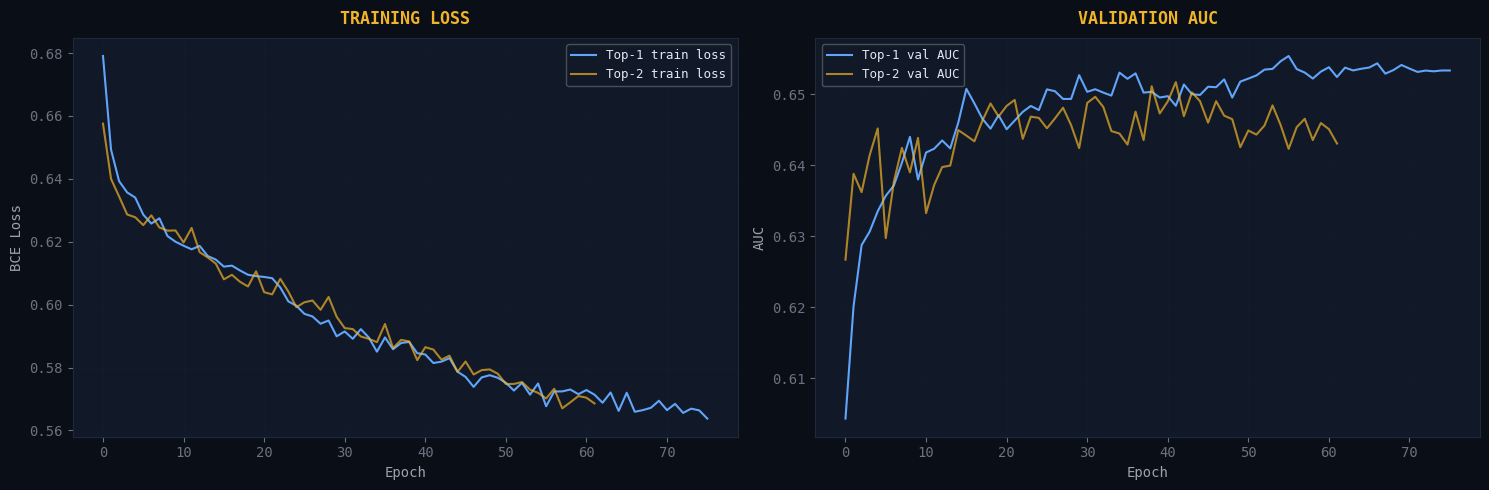

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Loss curve ──
ax = axes[0]
ax.plot(hist1["train_loss"], color=BLUE, linewidth=1.5, label="Top-1 train loss")
ax.plot(hist2["train_loss"], color=AMBER, linewidth=1.5, label="Top-2 train loss", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("TRAINING LOSS", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

# ── Val AUC curve ──
ax = axes[1]
ax.plot(hist1["val_auc"], color=BLUE, linewidth=1.5, label="Top-1 val AUC")
ax.plot(hist2["val_auc"], color=AMBER, linewidth=1.5, label="Top-2 val AUC", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_title("VALIDATION AUC", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 8b · Decile Curve & ROC

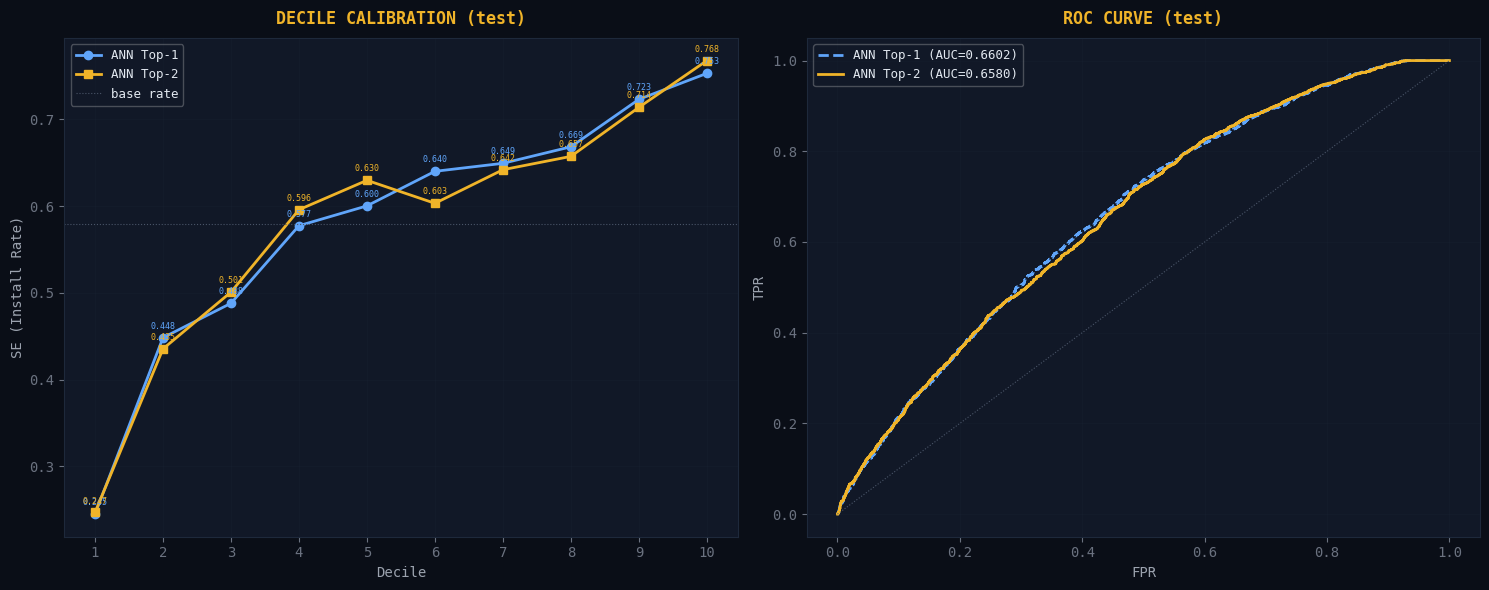

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Decile curves ──
ax = axes[0]
for preds, label, color, marker in [
    (p1_test,  f"ANN Top-1", BLUE,  "o"),
    (p2_test,  f"ANN Top-2", AMBER, "s"),
]:
    edf = pd.DataFrame({"y": y_test.values, "p": preds})
    edf["d"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("d").agg(n=("y","count"), inst=("y","sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    d = list(range(1, len(tbl) + 1))
    ax.plot(d, tbl["se"].values, f"{marker}-", color=color, linewidth=2, markersize=6, label=label)
    for j, se in enumerate(tbl["se"].values):
        ax.annotate(f"{se:.3f}", (j+1, se), fontsize=6, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points", color=color)

ax.axhline(y_test.mean(), color=GRAY, linestyle=":", linewidth=0.8, label="base rate")
ax.set_xlabel("Decile")
ax.set_ylabel("SE (Install Rate)")
ax.set_title("DECILE CALIBRATION (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.set_xticks(range(1, 11))
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

# ── ROC ──
ax = axes[1]
for preds, label, color, ls in [
    (p1_test,  "ANN Top-1", BLUE,  "--"),
    (p2_test,  "ANN Top-2", AMBER, "-"),
]:
    fpr, tpr, _ = roc_curve(y_test, preds)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=ls, label=f"{label} (AUC={a:.4f})")

ax.plot([0, 1], [0, 1], ":", color=GRAY, linewidth=0.8)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC CURVE (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### 8c · Feature Saliency (gradient-based importance)

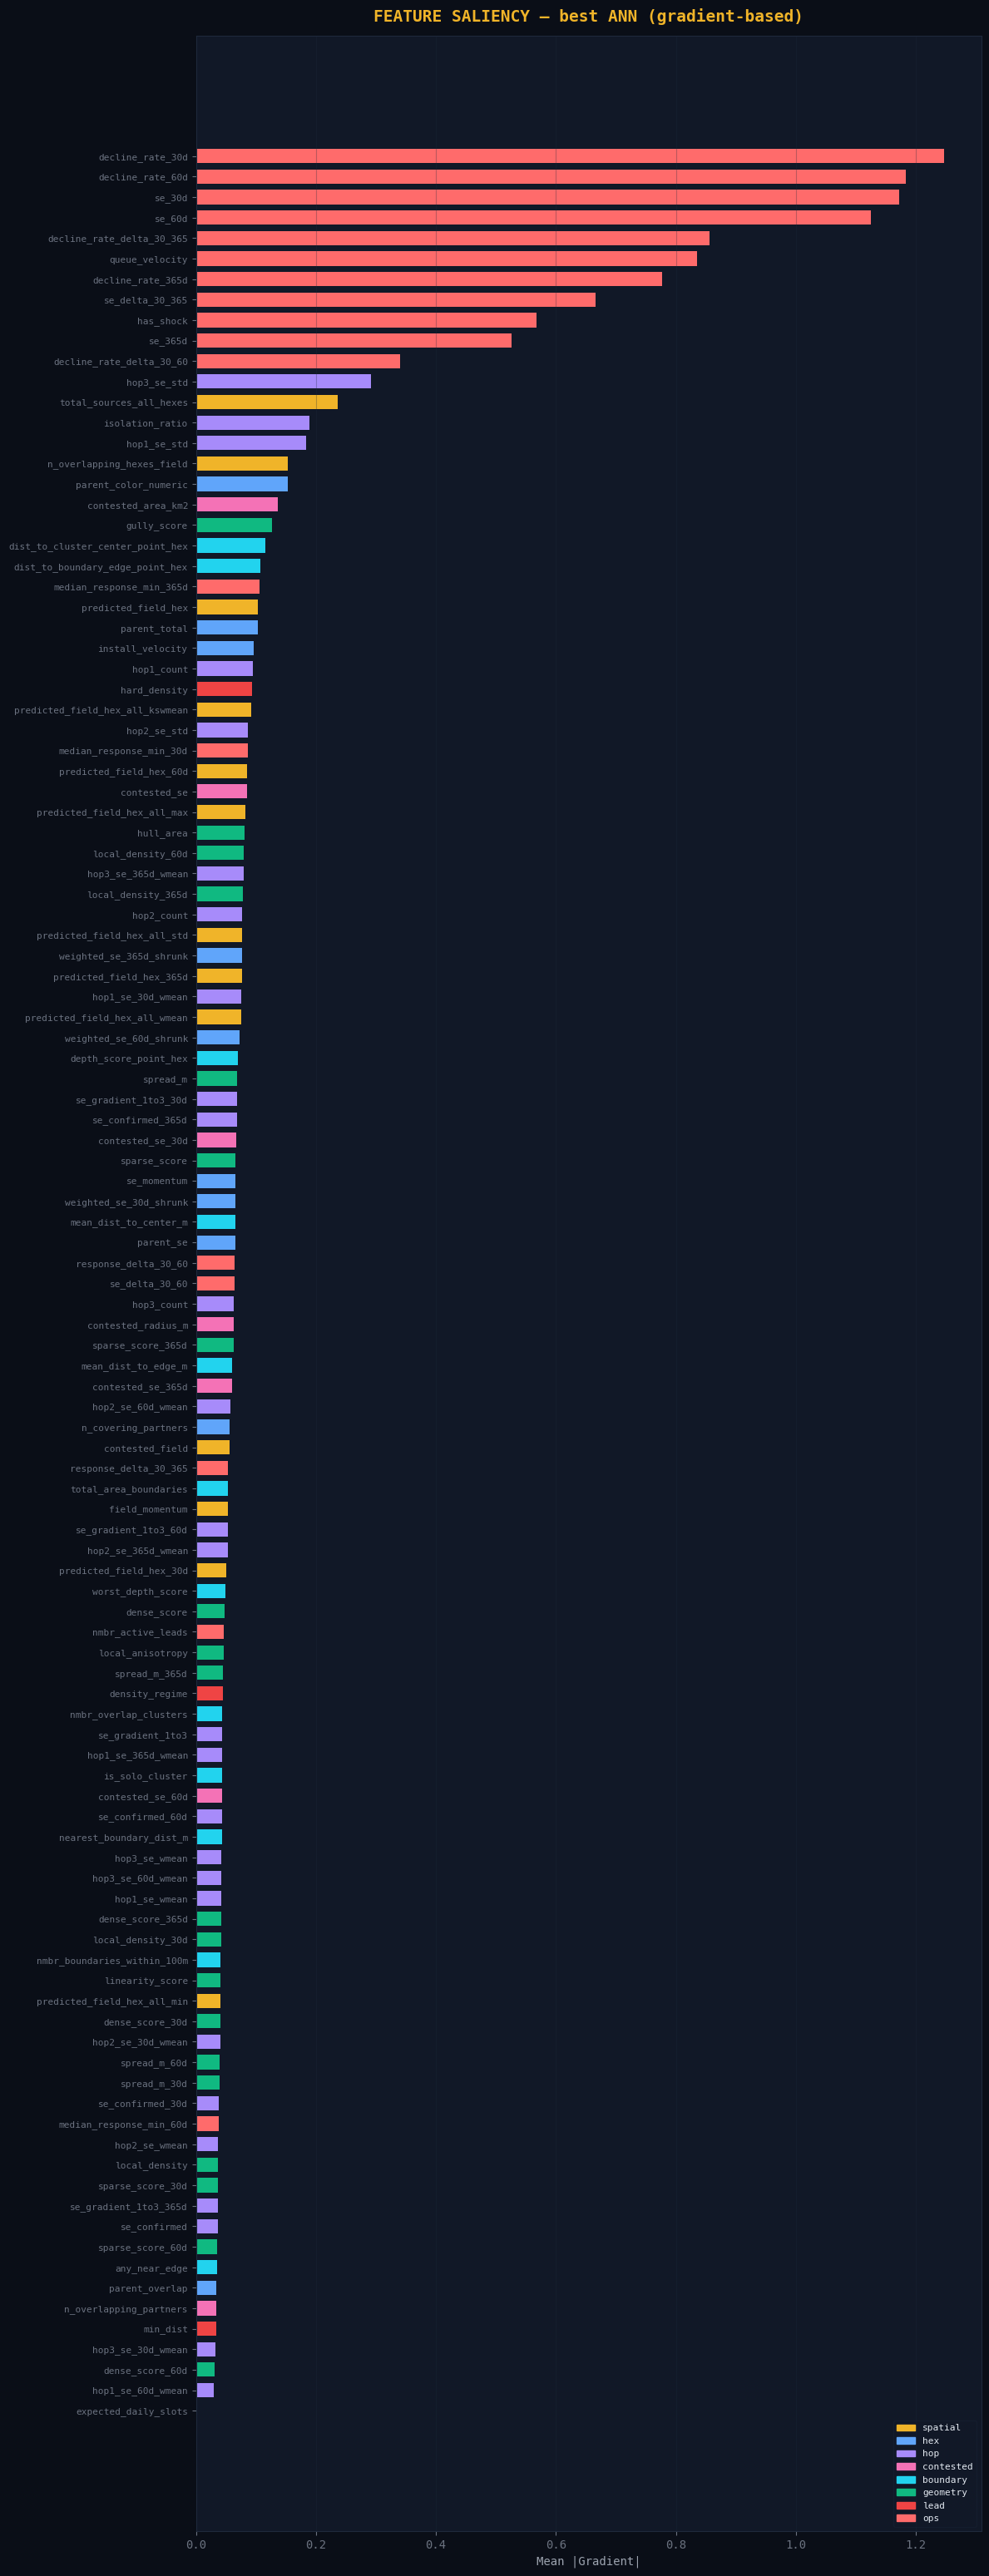

In [13]:
# ── Gradient-based feature importance (mean |∂output/∂input|) ──
best_model_dive = best_m1
best_model_dive.eval()

X_tens = torch.tensor(X_test_sc, dtype=torch.float32, requires_grad=True).to(DEVICE)
out = best_model_dive(X_tens)
out.sum().backward()

grad_imp = X_tens.grad.abs().mean(dim=0).cpu().numpy()

# ── Family color map (same as tree notebook) ──
_families = {
    "spatial": [
        "predicted_field_hex", "predicted_field_hex_all_wmean", "predicted_field_hex_all_kswmean",
        "predicted_field_hex_all_min", "predicted_field_hex_all_max", "predicted_field_hex_all_std",
        "n_overlapping_hexes_field", "total_sources_all_hexes", "contested_field",
        "predicted_field_hex_30d", "predicted_field_hex_60d", "predicted_field_hex_365d",
        "field_momentum",
    ],
    "hex": [
        "parent_se", "parent_total", "parent_color_numeric", "n_covering_partners",
        "parent_overlap", "install_velocity",
        "weighted_se_30d_shrunk", "weighted_se_60d_shrunk", "weighted_se_365d_shrunk",
        "se_momentum",
    ],
    "hop": [
        "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
        "hop1_se_std", "hop2_se_std", "hop3_se_std",
        "hop1_count", "hop2_count", "hop3_count",
        "se_gradient_1to3", "se_confirmed", "isolation_ratio",
        "hop1_se_30d_wmean", "hop2_se_30d_wmean", "hop3_se_30d_wmean",
        "hop1_se_60d_wmean", "hop2_se_60d_wmean", "hop3_se_60d_wmean",
        "hop1_se_365d_wmean", "hop2_se_365d_wmean", "hop3_se_365d_wmean",
        "se_gradient_1to3_30d", "se_gradient_1to3_60d", "se_gradient_1to3_365d",
        "se_confirmed_30d", "se_confirmed_60d", "se_confirmed_365d",
    ],
    "contested": [
        "contested_area_km2", "contested_radius_m", "contested_se",
        "contested_se_30d", "contested_se_60d", "contested_se_365d",
        "n_overlapping_partners",
    ],
    "boundary": [
        "dist_to_boundary_edge_point_hex", "dist_to_cluster_center_point_hex",
        "depth_score_point_hex", "mean_dist_to_edge_m", "mean_dist_to_center_m",
        "total_area_boundaries", "nmbr_overlap_clusters",
        "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
        "worst_depth_score", "any_near_edge", "is_solo_cluster",
    ],
    "geometry": [
        "local_anisotropy", "local_density", "hull_area", "linearity_score", "spread_m",
        "dense_score", "gully_score", "sparse_score",
        "local_density_30d", "local_density_60d", "local_density_365d",
        "dense_score_30d", "dense_score_60d", "dense_score_365d",
        "sparse_score_30d", "sparse_score_60d", "sparse_score_365d",
        "spread_m_30d", "spread_m_60d", "spread_m_365d",
    ],
    "lead": ["hard_density", "density_regime", "min_dist"],
    "ops": _ops_feature_cols,
}
family_map = {}
for fam, feats in _families.items():
    for f in feats:
        family_map[f] = fam

fam_colors = {
    "spatial": AMBER, "hex": BLUE, "hop": PURPLE, "contested": PINK,
    "boundary": CYAN, "geometry": GREEN, "lead": RED, "ops": "#ff6b6b",
}

imp = pd.Series(grad_imp, index=available).sort_values(ascending=True)
colors = [fam_colors.get(family_map.get(f, ""), GRAY) for f in imp.index]

fig, ax = plt.subplots(figsize=(12, max(10, len(imp) * 0.28)))
ax.barh(range(len(imp)), imp.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel("Mean |Gradient|")
ax.set_title("FEATURE SALIENCY — best ANN (gradient-based)", fontsize=14, fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

## 9 · Correlation & Collinearity Analysis

In [14]:
# ── Feature vs target correlation ──
feat_df = df[available + [TARGET]].copy()
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation with installed_decision:\n")
for feat, val in corr_target.items():
    bar = "\u2588" * int(abs(val) * 200)
    sign = "+" if val >= 0 else "-"
    print(f"  {sign}{abs(val):.4f}  {feat:40s}  {bar}")

# ── High collinearity pairs ──
corr_matrix = df[available].corr()
high_corr = []
for i in range(len(available)):
    for j in range(i + 1, len(available)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((available[i], available[j], round(r, 3)))

high_corr.sort(key=lambda x: -abs(x[2]))
print(f"\nHighly correlated pairs (|r| > 0.7): {len(high_corr)}\n")
for a, b, r in high_corr[:30]:
    print(f"  {r:+.3f}  {a}  <->  {b}")

Correlation with installed_decision:

  +0.1967  se_60d                                    ███████████████████████████████████████
  +0.1948  se_30d                                    ██████████████████████████████████████
  +0.1856  contested_se_60d                          █████████████████████████████████████
  +0.1698  contested_se_365d                         █████████████████████████████████
  +0.1536  predicted_field_hex_60d                   ██████████████████████████████
  +0.1473  se_365d                                   █████████████████████████████
  +0.1454  contested_se_30d                          █████████████████████████████
  +0.1450  predicted_field_hex_30d                   ████████████████████████████
  +0.1399  se_delta_30_365                           ███████████████████████████
  +0.1381  predicted_field_hex_365d                  ███████████████████████████
  +0.1381  predicted_field_hex                       ███████████████████████████
  +0.1381  predicted_fie

ValueError: cannot convert float NaN to integer

### Importance vs Correlation scatter

In [ ]:
imp_desc = pd.Series(grad_imp, index=available)

fig, ax = plt.subplots(figsize=(10, 8))
for feat in imp_desc.index:
    c = fam_colors.get(family_map.get(feat, ""), GRAY)
    ax.scatter(corr_target.get(feat, 0), imp_desc[feat],
               c=c, s=60, alpha=0.85, edgecolor="white", linewidth=0.3, zorder=3)

for feat in imp_desc.nlargest(10).index:
    if feat in corr_target.index:
        ax.annotate(feat, (corr_target[feat], imp_desc[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Pearson r with target")
ax.set_ylabel("Gradient Saliency")
ax.set_title("SALIENCY vs CORRELATION", fontsize=11, fontweight="bold", color=AMBER, pad=12)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

## 10 · Comparison with Existing Scores

In [ ]:
# Score the full dataset with best ANN
X_full_raw = df[available].fillna(FILL_VALUE)
X_full_sc  = scaler.transform(X_full_raw)
# Replace fill sentinel
for col_idx in range(X_full_sc.shape[1]):
    fv = fill_scaled[0, col_idx]
    X_full_sc[X_full_sc[:, col_idx] == fv, col_idx] = 0.0

df["ann_score"] = predict_np(best_m1, X_full_sc)

def score_summary(score_col):
    """Compute AUC, decile gap, mono for a score column on full labelled data."""
    mask = df[TARGET].notna()
    sub = df[mask]
    auc_val = roc_auc_score(sub[TARGET], sub[score_col])
    d = pd.qcut(sub[score_col], q=10, labels=False, duplicates="drop") + 1
    tbl = sub.groupby(d).agg(n=(TARGET, "count"), inst=(TARGET, "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    gap = (tbl["se"].iloc[-1] - tbl["se"].iloc[0]) * 100
    mono = bool((tbl["se"].diff().dropna() >= 0).all())
    comp = auc_val * 100 + gap
    return auc_val, gap, mono, comp

print(f"{'Score':25s}  {'AUC':>7s}  {'gap_pp':>7s}  {'composite':>10s}  {'mono':>5s}")
print("-" * 62)
for col in ["ann_score", "composite_score", "spatial_shrunk"]:
    if col in df.columns:
        a, g, m, c = score_summary(col)
        print(f"{col:25s}  {a:7.4f}  {g:7.2f}  {c:10.2f}  {str(m):>5s}")